## 0. Imports & Config

In [182]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

DATA_DIR = '../data/'

EPA_FILE = DATA_DIR + 'EPA_SmartLocationDatabase_V3_Jan_2021_Final.csv'
PLACES_FILE = DATA_DIR + 'PLACES__Local_Data_for_Better_Health,_Census_Tract_Data,_2025_release_20260404.csv'

## 1. Load Data

In [183]:
# EPA Smart Location Database (block group level)
# GEOID20 is stored as scientific notation in the CSV — read component FIPS columns as strings instead
epa = pd.read_csv(EPA_FILE, dtype={'STATEFP': str, 'COUNTYFP': str, 'TRACTCE': str})
print(f'EPA shape: {epa.shape}')
epa.head(2)

EPA shape: (220740, 117)


,OBJECTID,GEOID10,GEOID20,STATEFP,COUNTYFP,TRACTCE,BLKGRPCE,CSA,CSA_Name,CBSA,CBSA_Name,CBSA_POP,CBSA_EMP,CBSA_WRK,Ac_Total,Ac_Water,Ac_Land,Ac_Unpr,TotPop,CountHU,HH,P_WrkAge,AutoOwn0,Pct_AO0,AutoOwn1,...,D4A,D4B025,D4B050,D4C,D4D,D4E,D5AR,D5AE,D5BR,D5BE,D5CR,D5CRI,D5CE,D5CEI,D5DR,D5DRI,D5DE,D5DEI,D2A_Ranked,D2B_Ranked,D3B_Ranked,D4A_Ranked,NatWalkInd,Shape_Length,Shape_Area
0,1,481130000000.0000,481130000000.0000,48,113,7825,4,206.0000,"Dallas-Fort Worth, TX-OK",19100.0000,"Dallas-Fort Worth-Arlington, TX",7189384,3545715,3364458,73.5950,0.0000,73.5950,73.5950,1202,460.0000,423.0000,0.5490,69,0.1631,39,...,362.1000,0.0000,0.0000,4.3300,37.6547,0.0036,433601,303660,135362,53504,0.0004,0.7859,0.0004,0.8413,0.0005,0.1847,0.0005,0.1377,6,14,15,17,14.0000,3110.3608,297836.0831
1,2,481130000000.0000,481130000000.0000,48,113,7825,2,206.0000,"Dallas-Fort Worth, TX-OK",19100.0000,"Dallas-Fort Worth-Arlington, TX",7189384,3545715,3364458,119.8299,0.0000,119.8299,119.2142,710,409.0000,409.0000,0.4660,0,0.0000,168,...,718.8400,0.0000,0.0095,4.3300,23.1261,0.0061,386504,272135,236885,90089,0.0004,0.7005,0.0003,0.7540,0.0009,0.3232,0.0008,0.2319,3,10,12,14,10.8333,3519.4691,484945.1466


In [184]:
# CDC PLACES 2025 (census tract level)
places = pd.read_csv(PLACES_FILE, dtype={'LocationID': str})
print(f'PLACES shape: {places.shape}')
places.head(2)

PLACES shape: (3047284, 24)


,Year,StateAbbr,StateDesc,CountyName,CountyFIPS,LocationName,DataSource,Category,Measure,Data_Value_Unit,Data_Value_Type,Data_Value,Data_Value_Footnote_Symbol,Data_Value_Footnote,Low_Confidence_Limit,High_Confidence_Limit,TotalPopulation,TotalPop18plus,Geolocation,LocationID,CategoryID,MeasureId,DataValueTypeID,Short_Question_Text
0,2023,AL,Alabama,Jefferson,1073,1073010900,BRFSS,Disability,Any disability among adults,%,Crude prevalence,44.9000,NaN,NaN,40.7000,49.0000,"4,719","3,410",POINT (-86.7705771 33.5795996),01073010900,DISABLT,DISABILITY,CrdPrv,Any Disability
1,2023,AL,Alabama,Jefferson,1073,1073011207,BRFSS,Health Outcomes,Depression among adults,%,Crude prevalence,22.7000,NaN,NaN,19.9000,25.9000,"5,103","3,684",POINT (-86.6742325 33.6638358),01073011207,HLTHOUT,DEPRESSION,CrdPrv,Depression


## 2. Explore Schemas

In [185]:
print('EPA columns')
print(epa.dtypes.to_string())

EPA columns
OBJECTID          int64
GEOID10         float64
GEOID20         float64
STATEFP             str
COUNTYFP            str
TRACTCE             str
BLKGRPCE          int64
CSA             float64
CSA_Name            str
CBSA            float64
CBSA_Name           str
CBSA_POP          int64
CBSA_EMP          int64
CBSA_WRK          int64
Ac_Total        float64
Ac_Water        float64
Ac_Land         float64
Ac_Unpr         float64
TotPop            int64
CountHU         float64
HH              float64
P_WrkAge        float64
AutoOwn0          int64
Pct_AO0         float64
AutoOwn1          int64
Pct_AO1         float64
AutoOwn2p         int64
Pct_AO2p        float64
Workers           int64
R_LowWageWk       int64
R_MedWageWk       int64
R_HiWageWk        int64
R_PCTLOWWAGE    float64
TotEmp            int64
E5_Ret            int64
E5_Off            int64
E5_Ind            int64
E5_Svc            int64
E5_Ent            int64
E8_Ret            int64
E8_off            int64
E8_I

In [186]:
print('PLACES columns')
print(places.dtypes.to_string())

PLACES columns
Year                            int64
StateAbbr                         str
StateDesc                         str
CountyName                        str
CountyFIPS                      int64
LocationName                    int64
DataSource                        str
Category                          str
Measure                           str
Data_Value_Unit                   str
Data_Value_Type                   str
Data_Value                    float64
Data_Value_Footnote_Symbol    float64
Data_Value_Footnote           float64
Low_Confidence_Limit          float64
High_Confidence_Limit         float64
TotalPopulation                   str
TotalPop18plus                    str
Geolocation                       str
LocationID                        str
CategoryID                        str
MeasureId                         str
DataValueTypeID                   str
Short_Question_Text               str


In [187]:
# Unique measures in PLACES
print(places['MeasureId'].unique())

<StringArray>
[  'DISABILITY',   'DEPRESSION',    'ARTHRITIS',      'OBESITY',
       'STROKE',     'DIABETES',       'CANCER',      'CASTHMA',
      'HEARING',       'VISION',        'BINGE',     'MOBILITY',
        'GHLTH',       'BPHIGH',          'CHD',        'MHLTH',
     'LACKTRPT',     'HIGHCHOL',         'COPD',     'MAMMOUSE',
     'SELFCARE',    'INDEPLIVE',    'COGNITION',   'FOODINSECU',
   'CHOLSCREEN',      'CHECKUP',        'SLEEP',   'HOUSINSECU',
 'COLON_SCREEN',        'PHLTH',          'LPA',   'EMOTIONSPT',
       'DENTAL',      'ACCESS2',     'CSMOKING',    'FOODSTAMP',
   'LONELINESS',    'TEETHLOST',  'SHUTUTILITY',        'BPMED']
Length: 40, dtype: str


## 3. Clean EPA Data

- Aggregate block groups to census tract level (GEOID = first 11 digits of GEOID20)
- Key columns: `NatWalkInd` (walkability), `Ac_Total`, `D3b`, `D4a`, etc.

In [188]:
# Build 11-digit census tract GEOID from component FIPS columns (avoids scientific notation precision loss in GEOID20)
epa['GEOID_tract'] = (
    epa['STATEFP'].str.zfill(2) +
    epa['COUNTYFP'].str.zfill(3) +
    epa['TRACTCE'].str.zfill(6)
)

# Aggregate walkability to tract level (mean across block groups)
epa_tract = epa.groupby('GEOID_tract').agg(
    walkability_mean=('NatWalkInd', 'mean'),
    walkability_min=('NatWalkInd', 'min'),
    walkability_max=('NatWalkInd', 'max'),
).reset_index()

print(f'EPA tract shape: {epa_tract.shape}')
print(f'Sample GEOIDs: {epa_tract["GEOID_tract"].head(3).tolist()}')
epa_tract.head()

EPA tract shape: (74133, 4)
Sample GEOIDs: ['01001020100', '01001020200', '01001020300']


/var/folders/gj/qdh0ngnx7z9c285qtz68rshc0000gn/T/ipykernel_28371/4292615626.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  epa['GEOID_tract'] = (


,GEOID_tract,walkability_mean,walkability_min,walkability_max
0,01001020100,4.0833,2.6667,5.5000
1,01001020200,8.5833,7.6667,9.5000
2,01001020300,6.8333,4.6667,9.0000
3,01001020400,7.5417,6.0000,10.0000
4,01001020500,7.8889,6.1667,9.5000


In [189]:
# Missing values
print('EPA tract nulls:')
print(epa_tract.isnull().sum())

EPA tract nulls:
GEOID_tract         0
walkability_mean    0
walkability_min     0
walkability_max     0
dtype: int64


## 4. Clean PLACES Data

- Filter to obesity (`OBESITY`) and diabetes (`DIABETES`) measures
- Pivot wide so each tract has one row

In [190]:
# Filter to target health outcomes
target_measures = ['OBESITY', 'DIABETES']
places_filtered = places[places['MeasureId'].isin(target_measures)].copy()

print(f'Filtered PLACES shape: {places_filtered.shape}')
places_filtered['MeasureId'].value_counts()

Filtered PLACES shape: (157630, 24)


MeasureId
OBESITY     78815
DIABETES    78815
Name: count, dtype: int64

In [191]:
# Pivot to wide format (one row per census tract)
places_wide = places_filtered.pivot_table(
    index='LocationID',
    columns='MeasureId',
    values='Data_Value',
    aggfunc='first'
).reset_index()

places_wide.columns.name = None
places_wide = places_wide.rename(columns={
    'LocationID': 'GEOID_tract',
    'OBESITY': 'obesity_pct',
    'DIABETES': 'diabetes_pct',
})

print(f'PLACES wide shape: {places_wide.shape}')
places_wide.head(10)

PLACES wide shape: (78815, 3)


,GEOID_tract,diabetes_pct,obesity_pct
0,01001020100,13.3000,39.4000
1,01001020200,15.8000,44.7000
2,01001020300,13.9000,40.3000
3,01001020400,12.8000,36.9000
4,01001020501,10.2000,34.7000
5,01001020502,10.0000,38.2000
6,01001020503,11.8000,38.1000
7,01001020600,13.5000,40.7000
8,01001020700,14.0000,42.6000
9,01001020801,12.8000,38.4000


In [192]:
# Missing values
print('PLACES wide nulls:')
print(places_wide.isnull().sum())

PLACES wide nulls:
GEOID_tract     0
diabetes_pct    0
obesity_pct     0
dtype: int64


## 5. Merge Datasets

In [193]:
df = epa_tract.merge(places_wide, on='GEOID_tract', how='inner')

print(f'Merged shape: {df.shape}')
print(f'\nNulls:\n{df.isnull().sum()}')
df = df.dropna()


df.head()

Merged shape: (56336, 6)

Nulls:
GEOID_tract         0
walkability_mean    0
walkability_min     0
walkability_max     0
diabetes_pct        0
obesity_pct         0
dtype: int64


,GEOID_tract,walkability_mean,walkability_min,walkability_max,diabetes_pct,obesity_pct
0,01001020100,4.0833,2.6667,5.5000,13.3000,39.4000
1,01001020200,8.5833,7.6667,9.5000,15.8000,44.7000
2,01001020300,6.8333,4.6667,9.0000,13.9000,40.3000
3,01001020400,7.5417,6.0000,10.0000,12.8000,36.9000
4,01001020600,4.5833,4.5000,4.6667,13.5000,40.7000


In [194]:
# Drop rows missing outcome variables
df = df.dropna(subset=['obesity_pct', 'diabetes_pct'])
print(f'After dropping nulls: {df.shape}')

After dropping nulls: (56336, 6)


## 6. Exploratory Data Analysis

In [195]:
df[['walkability_mean', 'obesity_pct', 'diabetes_pct']].describe()

,walkability_mean,obesity_pct,diabetes_pct
count,56336.0000,56336.0000,56336.0000
mean,9.7862,34.2038,12.6433
std,4.0213,7.5487,4.0676
min,1.0000,11.6000,0.7000
25%,6.3333,28.9000,10.0000
50%,9.5000,34.3000,12.1000
75%,13.3333,39.2000,14.6000
max,19.8333,64.3000,50.8000


In [196]:
# Correlation matrix
corr_cols = ['walkability_mean', 'obesity_pct', 'diabetes_pct']
print(df[corr_cols].corr().round(3))

                  walkability_mean  obesity_pct  diabetes_pct
walkability_mean            1.0000      -0.2780       -0.1230
obesity_pct                -0.2780       1.0000        0.7220
diabetes_pct               -0.1230       0.7220        1.0000


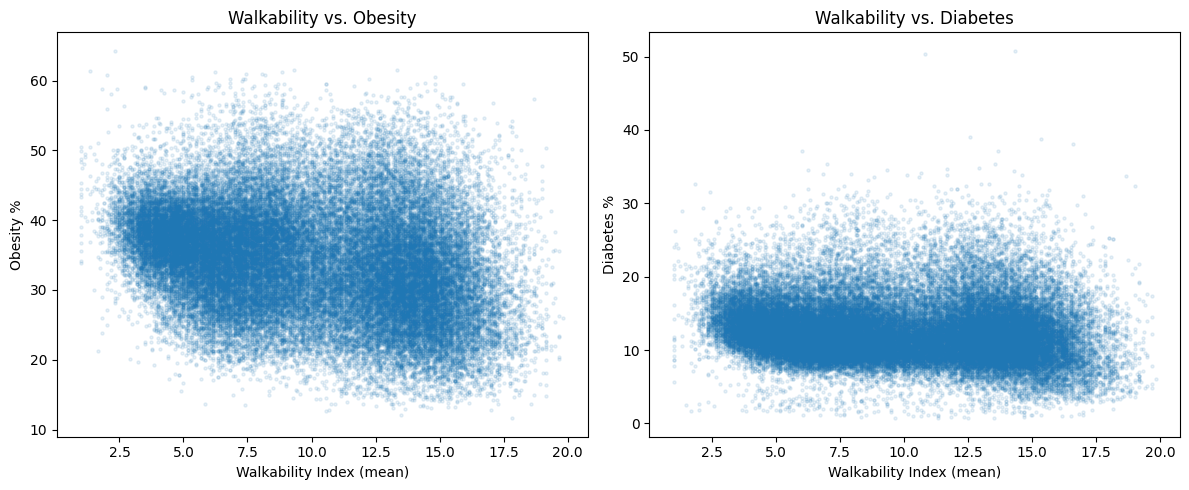

In [197]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(df['walkability_mean'], df['obesity_pct'], alpha=0.1, s=5)
axes[0].set_xlabel('Walkability Index (mean)')
axes[0].set_ylabel('Obesity %')
axes[0].set_title('Walkability vs. Obesity')

axes[1].scatter(df['walkability_mean'], df['diabetes_pct'], alpha=0.1, s=5)
axes[1].set_xlabel('Walkability Index (mean)')
axes[1].set_ylabel('Diabetes %')
axes[1].set_title('Walkability vs. Diabetes')

plt.tight_layout()
plt.show()

In [198]:
FOOD_FILE = pd.read_csv(DATA_DIR + 'food_access.csv')

In [199]:
food = FOOD_FILE
print(f'FOOD shape: {food.shape}')
food.head(2)

FOOD shape: (72531, 147)


,CensusTract,State,County,Urban,Pop2010,OHU2010,GroupQuartersFlag,NUMGQTRS,PCTGQTRS,LILATracts_1And10,LILATracts_halfAnd10,LILATracts_1And20,LILATracts_Vehicle,HUNVFlag,LowIncomeTracts,PovertyRate,MedianFamilyIncome,LA1and10,LAhalfand10,LA1and20,LATracts_half,LATracts1,LATracts10,LATracts20,LATractsVehicle_20,...,laasian20share,lanhopi20,lanhopi20share,laaian20,laaian20share,laomultir20,laomultir20share,lahisp20,lahisp20share,lahunv20,lahunv20share,lasnap20,lasnap20share,TractLOWI,TractKids,TractSeniors,TractWhite,TractBlack,TractAsian,TractNHOPI,TractAIAN,TractOMultir,TractHispanic,TractHUNV,TractSNAP
0,1001020100,Alabama,Autauga County,1,1912,693,0,0.0000,0.0000,0,0,0,0,0,0,11.3365,81250.0000,1,1,1,1,1,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,455.0000,507.0000,221.0000,1622.0000,217.0000,14.0000,0.0000,14.0000,45.0000,44.0000,6.0000,102.0000
1,1001020200,Alabama,Autauga County,1,2170,743,0,181.0000,8.3410,1,1,1,0,0,1,17.8768,49000.0000,1,1,1,1,1,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,802.0000,606.0000,214.0000,888.0000,1217.0000,5.0000,0.0000,5.0000,55.0000,75.0000,89.0000,156.0000


In [200]:
print('food nulls:')
x = food.isnull().sum()
x = x[x > 1000]
print(x)

food nulls:
LAPOP1_10        29957
LAPOP05_10       14540
LAPOP1_20        35914
LALOWI1_10       29957
LALOWI05_10      14540
                 ...  
lahisp20share    71025
lahunv20         71025
lahunv20share    70920
lasnap20         71025
lasnap20share    70920
Length: 110, dtype: int64


### Select Key Food Access Variables

The USDA Food Access Research Atlas has 140+ columns. We keep only the variables relevant to our research questions:
- **Food desert flags** (LILA = Low Income + Low Access)
- **Low-access population shares** at the 1-mile threshold
- **No-vehicle + low-access** population (interaction of interest)
- **Poverty rate** and **median family income** as cross-checks against Census ACS

In [201]:
food_vars = [
    'CensusTract',          # join key

    'LILATracts_1And10',    # primary food desert flag: low income + low access (1mi urban / 10mi rural)
    'LILATracts_halfAnd10', # stricter: half-mile urban / 10-mile rural
    'LILATracts_Vehicle',   # low income + low access measured by vehicle distance
    'LowIncomeTracts',      # low income flag (independent of access)
    'lapop1share',          # share of tract pop with low access at 1 mile
    'lalowi1share',         # share of low-income pop with low access at 1 mile
    'lahunv1',              # count of no-vehicle HHs with low access at 1 mile
    'lahunv1share',         # share of no-vehicle HHs with low access at 1 mile
    'PovertyRate',          # tract poverty rate
    'MedianFamilyIncome',   # tract median family income (cross-check vs Census MHI)
    'Urban',                # urban tract
]

food_slim = food[food_vars].copy()
food_slim['CensusTract'] = food_slim['CensusTract'].astype(str).str.zfill(11)

print(f'food_slim shape: {food_slim.shape}')
print(f'Nulls:\n{food_slim.isnull().sum()}')
food_slim.head()

food_slim shape: (72531, 12)
Nulls:
CensusTract                 0
LILATracts_1And10           0
LILATracts_halfAnd10        0
LILATracts_Vehicle          0
LowIncomeTracts             0
lapop1share             19989
lalowi1share            19989
lahunv1                 19989
lahunv1share            19966
PovertyRate                 3
MedianFamilyIncome        748
Urban                       0
dtype: int64


,CensusTract,LILATracts_1And10,LILATracts_halfAnd10,LILATracts_Vehicle,LowIncomeTracts,lapop1share,lalowi1share,lahunv1,lahunv1share,PovertyRate,MedianFamilyIncome,Urban
0,01001020100,0,0,0,0,99.1890,24.1108,5.4904,0.7923,11.3365,81250.0000,1
1,01001020200,1,1,0,1,58.1102,27.8292,66.9035,9.0045,17.8768,49000.0000,1
2,01001020300,0,0,0,0,46.0037,14.1791,0.0000,0.0000,15.0460,62609.0000,1
3,01001020400,0,0,0,0,31.0868,7.8253,7.9414,0.4612,2.8452,70607.0000,1
4,01001020500,0,0,0,0,24.5504,5.4469,55.2119,1.3526,15.1509,96334.0000,1


In [202]:
import os
from census import Census

CENSUS_API_KEY = os.environ.get('CENSUS_API_KEY')
if not CENSUS_API_KEY:
    raise EnvironmentError('Set the CENSUS_API_KEY environment variable before running this cell.')

c = Census(CENSUS_API_KEY)

In [203]:
import pandas as pd

variables = ('NAME', 'B19013_001E', 'B08201_002E', 'B03002_003E', 'B03002_004E', 'B03002_012E', 'B01003_001E', 'B11001_001E')
results = []

for state_fips in c.acs5.get('NAME', {'for': 'state:*'}):
    fips = state_fips['state']
    data = c.acs5.state_county_tract(variables, fips, '*', '*')
    results.extend(data)

CENSUS = pd.DataFrame(results)

In [204]:
CENSUS = CENSUS.rename(columns={'B19013_001E': 'MHI', 'B08201_002E': 'NO_VEHICLE_HOUSEHOLDS', 'B03002_003E': 'NON-HISPANIC WHITE POPULATION', 'B03002_004E': 'BLACK POPULATION', 'B03002_012E': 'HISPANIC POPULATION', 'B01003_001E': 'TOTAL POPULATION', 'B11001_001E': 'TOTAL HOUSEHOLDS'})
CENSUS.head()

,NAME,MHI,NO_VEHICLE_HOUSEHOLDS,NON-HISPANIC WHITE POPULATION,BLACK POPULATION,HISPANIC POPULATION,TOTAL POPULATION,TOTAL HOUSEHOLDS,state,county,tract
0,Census Tract 201; Autauga County; Alabama,62407.0000,36.0000,1302.0000,165.0000,196.0000,1840.0000,672.0000,01,001,020100
1,Census Tract 202; Autauga County; Alabama,59028.0000,37.0000,842.0000,916.0000,23.0000,2017.0000,572.0000,01,001,020200
2,Census Tract 203; Autauga County; Alabama,66698.0000,104.0000,2328.0000,950.0000,38.0000,3515.0000,1253.0000,01,001,020300
3,Census Tract 204; Autauga County; Alabama,75956.0000,102.0000,3401.0000,241.0000,78.0000,3913.0000,1648.0000,01,001,020400
4,Census Tract 205.01; Autauga County; Alabama,81936.0000,0.0000,3192.0000,439.0000,198.0000,4053.0000,1834.0000,01,001,020501


In [205]:
DEMOGRAPHICS = CENSUS.iloc[:, [3,4,5]].apply(lambda x: x / CENSUS[CENSUS.columns[6]])

In [206]:
DEMOGRAPHICS = DEMOGRAPHICS.rename(columns={'NON-HISPANIC WHITE POPULATION': 'NHW PERCENT', 'BLACK POPULATION': 'BLACK PERCENT', 'HISPANIC POPULATION': 'HISPANIC PERCENT'})
DEMOGRAPHICS['NO_VEHICLE_RATIO'] = CENSUS['NO_VEHICLE_HOUSEHOLDS'] / CENSUS['TOTAL HOUSEHOLDS']
DEMOGRAPHICS['TRACT'] = CENSUS['state'] + CENSUS['county'] + CENSUS['tract']
DEMOGRAPHICS['MHI'] = CENSUS['MHI']
DEMOGRAPHICS.head()

,NHW PERCENT,BLACK PERCENT,HISPANIC PERCENT,NO_VEHICLE_RATIO,TRACT,MHI
0,0.7076,0.0897,0.1065,0.0536,01001020100,62407.0000
1,0.4175,0.4541,0.0114,0.0647,01001020200,59028.0000
2,0.6623,0.2703,0.0108,0.0830,01001020300,66698.0000
3,0.8692,0.0616,0.0199,0.0619,01001020400,75956.0000
4,0.7876,0.1083,0.0489,0.0000,01001020501,81936.0000


In [207]:
df.head()

,GEOID_tract,walkability_mean,walkability_min,walkability_max,diabetes_pct,obesity_pct
0,01001020100,4.0833,2.6667,5.5000,13.3000,39.4000
1,01001020200,8.5833,7.6667,9.5000,15.8000,44.7000
2,01001020300,6.8333,4.6667,9.0000,13.9000,40.3000
3,01001020400,7.5417,6.0000,10.0000,12.8000,36.9000
4,01001020600,4.5833,4.5000,4.6667,13.5000,40.7000


In [208]:
df = df.merge(
    DEMOGRAPHICS,
    left_on='GEOID_tract',
    right_on='TRACT',
    how='left'
).drop(columns='TRACT')

print(f'Shape after demographics merge: {df.shape}')
print(f'\nNulls:\n{df.isnull().sum()}')
df.head()

Shape after demographics merge: (56336, 11)

Nulls:
GEOID_tract           0
walkability_mean      0
walkability_min       0
walkability_max       0
diabetes_pct          0
obesity_pct           0
NHW PERCENT          19
BLACK PERCENT        19
HISPANIC PERCENT     19
NO_VEHICLE_RATIO    145
MHI                  12
dtype: int64


,GEOID_tract,walkability_mean,walkability_min,walkability_max,diabetes_pct,obesity_pct,NHW PERCENT,BLACK PERCENT,HISPANIC PERCENT,NO_VEHICLE_RATIO,MHI
0,01001020100,4.0833,2.6667,5.5000,13.3000,39.4000,0.7076,0.0897,0.1065,0.0536,62407.0000
1,01001020200,8.5833,7.6667,9.5000,15.8000,44.7000,0.4175,0.4541,0.0114,0.0647,59028.0000
2,01001020300,6.8333,4.6667,9.0000,13.9000,40.3000,0.6623,0.2703,0.0108,0.0830,66698.0000
3,01001020400,7.5417,6.0000,10.0000,12.8000,36.9000,0.8692,0.0616,0.0199,0.0619,75956.0000
4,01001020600,4.5833,4.5000,4.6667,13.5000,40.7000,0.6815,0.2034,0.0645,0.0228,75375.0000


## 7. Data Cleaning

Drop rows missing key demographic controls so regression later has a clean dataset.

In [209]:
# Inspect what we have after all merges
key_cols = ['walkability_mean', 'obesity_pct', 'diabetes_pct',
            'MHI', 'NHW PERCENT', 'BLACK PERCENT', 'HISPANIC PERCENT', 'NO_VEHICLE_RATIO']
print(f'Shape: {df.shape}')
print(f'\nNulls:')
print(df[key_cols].isnull().sum())

Shape: (56336, 11)

Nulls:
walkability_mean      0
obesity_pct           0
diabetes_pct          0
MHI                  12
NHW PERCENT          19
BLACK PERCENT        19
HISPANIC PERCENT     19
NO_VEHICLE_RATIO    145
dtype: int64


In [210]:
# Drop tracts missing any key control variable
before = len(df)
df = df.dropna(subset=key_cols)
print(f'Dropped {before - len(df)} rows with missing controls')
print(f'Final shape: {df.shape}')

Dropped 145 rows with missing controls
Final shape: (56191, 11)


In [211]:
# Rename columns for easier plotting
df = df.rename(columns={
    'NHW PERCENT': 'nhw_pct',
    'BLACK PERCENT': 'black_pct',
    'HISPANIC PERCENT': 'hispanic_pct',
    'NO_VEHICLE_RATIO': 'no_vehicle_ratio',
})

In [212]:
# Census API returns -666666666 as a sentinel for missing/suppressed MHI data
# Remove any row where MHI is negative (impossible in reality)
before = len(df)
df = df[df['MHI'] >= 0]
print(f'Removed {before - len(df)} rows with negative MHI (Census sentinel values)')
print(f'MHI range after cleaning: ${df["MHI"].min():,.0f} — ${df["MHI"].max():,.0f}')

Removed 216 rows with negative MHI (Census sentinel values)
MHI range after cleaning: $2,499 — $250,001


In [213]:
# Remove duplicate census tracts (keep first occurrence)
before = len(df)
df = df.drop_duplicates(subset='GEOID_tract')
print(f'Removed {before - len(df)} duplicate rows')
print(f'Final shape: {df.shape}')

Removed 0 duplicate rows
Final shape: (55975, 11)


## 8. Exploratory Data Analysis

### 8a. Summary Statistics

In [214]:
key_cols_new = ['walkability_mean', 'obesity_pct', 'diabetes_pct',
                'MHI', 'nhw_pct', 'black_pct', 'hispanic_pct', 'no_vehicle_ratio']
df[key_cols_new].describe().round(2)

,walkability_mean,obesity_pct,diabetes_pct,MHI,nhw_pct,black_pct,hispanic_pct,no_vehicle_ratio
count,55975.0000,55975.0000,55975.0000,55975.0000,55975.0000,55975.0000,55975.0000,55975.0000
mean,9.7900,34.1900,12.6500,83360.0000,0.5800,0.1300,0.1800,0.0900
std,4.0200,7.5200,4.0200,40962.2700,0.3000,0.2100,0.2200,0.1200
min,1.0000,11.6000,0.9000,2499.0000,0.0000,0.0000,0.0000,0.0000
25%,6.3300,28.8000,10.0000,55500.0000,0.3400,0.0100,0.0400,0.0200
50%,9.5000,34.3000,12.1000,74077.0000,0.6500,0.0400,0.1000,0.0500
75%,13.3300,39.2000,14.6000,101085.0000,0.8300,0.1500,0.2400,0.1100
max,19.8300,61.6000,50.8000,250001.0000,1.0000,1.0000,1.0000,0.9700


### 8b. Distributions of Key Variables

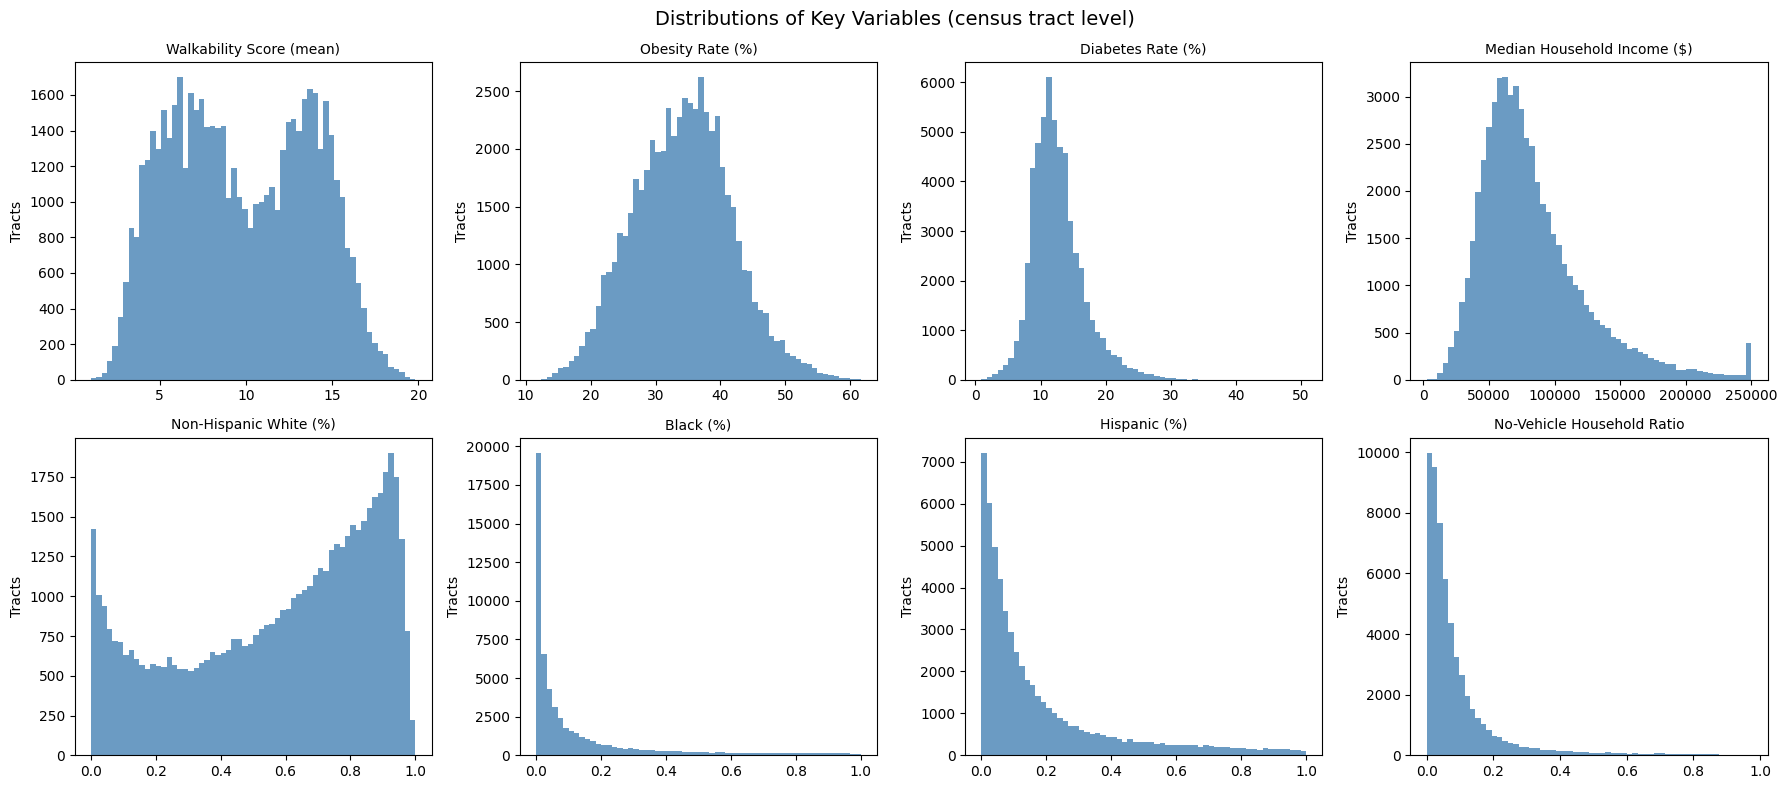

In [215]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Distributions of Key Variables (census tract level)', fontsize=14)

plot_vars = [
    ('walkability_mean', 'Walkability Score (mean)'),
    ('obesity_pct',      'Obesity Rate (%)'),
    ('diabetes_pct',     'Diabetes Rate (%)'),
    ('MHI',              'Median Household Income ($)'),
    ('nhw_pct',          'Non-Hispanic White (%)'),
    ('black_pct',        'Black (%)'),
    ('hispanic_pct',     'Hispanic (%)'),
    ('no_vehicle_ratio', 'No-Vehicle Household Ratio'),
]

for ax, (col, label) in zip(axes.flat, plot_vars):
    ax.hist(df[col].dropna(), bins=60, color='steelblue', edgecolor='none', alpha=0.8)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('Tracts')

plt.tight_layout()
plt.savefig('../data/distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### 8c. Correlation Heatmap

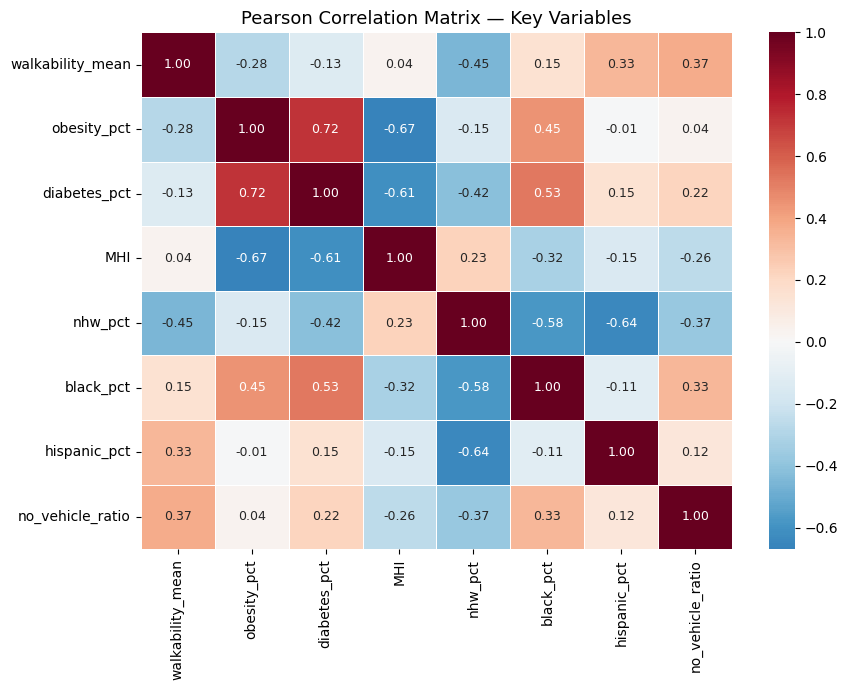

In [216]:
corr_cols = ['walkability_mean', 'obesity_pct', 'diabetes_pct',
              'MHI', 'nhw_pct', 'black_pct', 'hispanic_pct', 'no_vehicle_ratio']

corr = df[corr_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Pearson Correlation Matrix — Key Variables', fontsize=13)
plt.tight_layout()
plt.savefig('../data/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### 8d. Key Bivariate Relationships

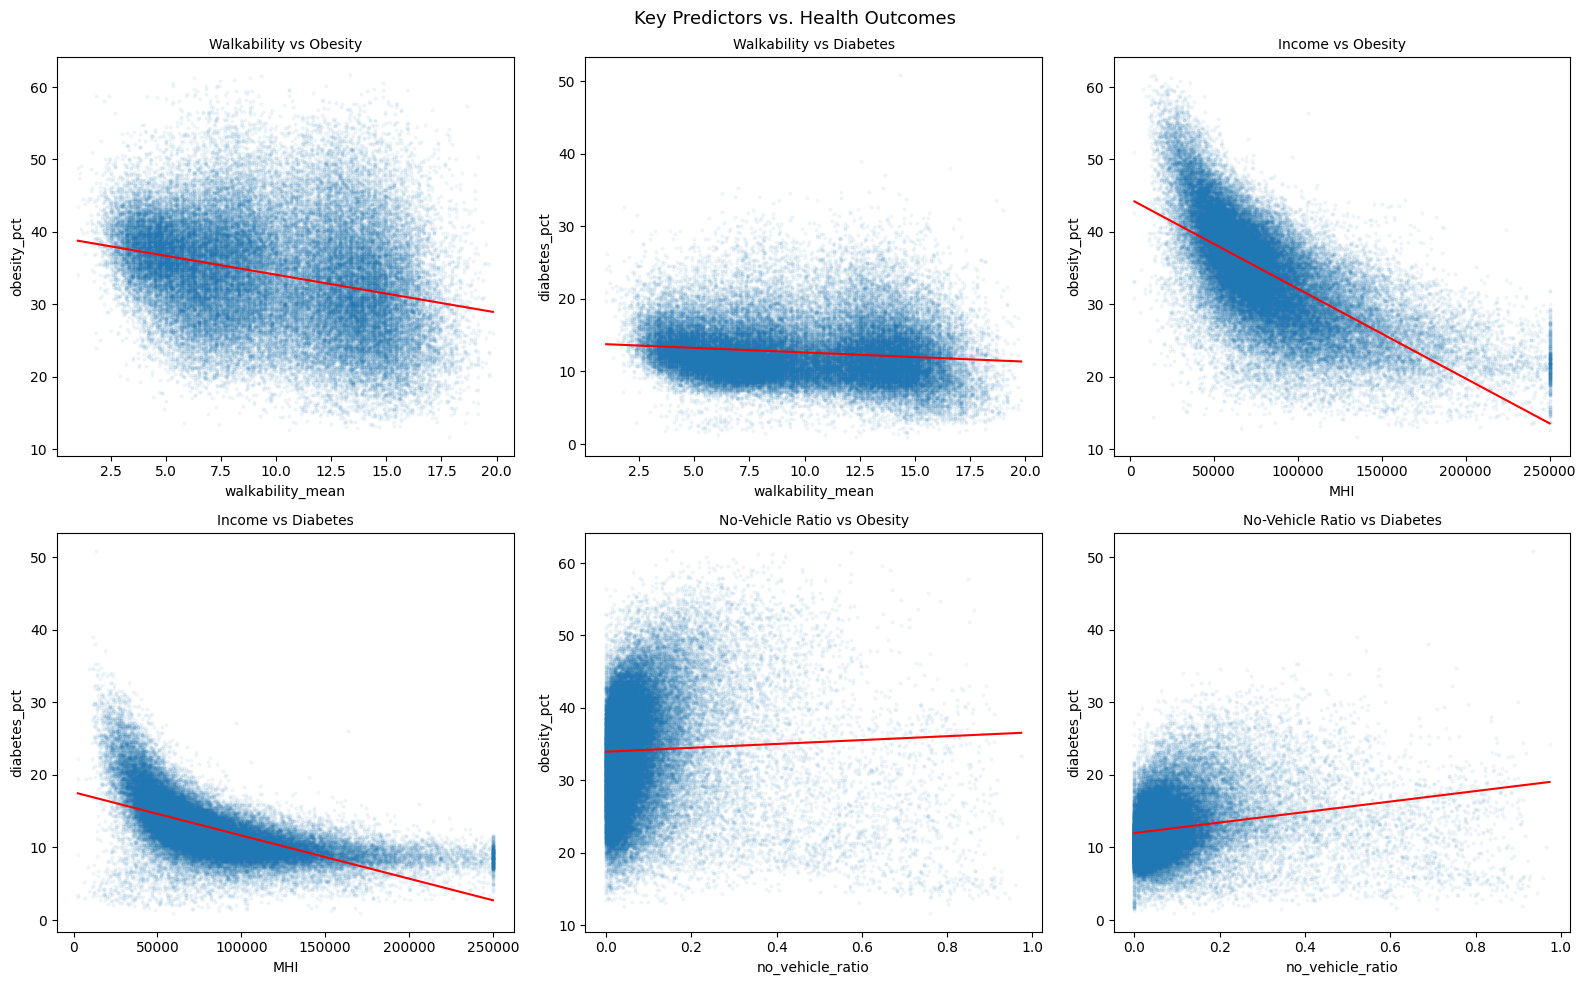

In [217]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Key Predictors vs. Health Outcomes', fontsize=13)

pairs = [
    ('walkability_mean', 'obesity_pct',      'Walkability vs Obesity'),
    ('walkability_mean', 'diabetes_pct',     'Walkability vs Diabetes'),
    ('MHI',             'obesity_pct',       'Income vs Obesity'),
    ('MHI',             'diabetes_pct',      'Income vs Diabetes'),
    ('no_vehicle_ratio','obesity_pct',       'No-Vehicle Ratio vs Obesity'),
    ('no_vehicle_ratio','diabetes_pct',      'No-Vehicle Ratio vs Diabetes'),
]

for ax, (x, y, title) in zip(axes.flat, pairs):
    ax.scatter(df[x], df[y], alpha=0.05, s=4)
    m, b = np.polyfit(df[x].dropna(), df[y].loc[df[x].dropna().index], 1)
    xs = np.linspace(df[x].min(), df[x].max(), 200)
    ax.plot(xs, m * xs + b, color = "red", linewidth=1.5)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(title, fontsize=10)

plt.tight_layout()
plt.savefig('../data/bivariate_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

### 8e. State-Level Variation

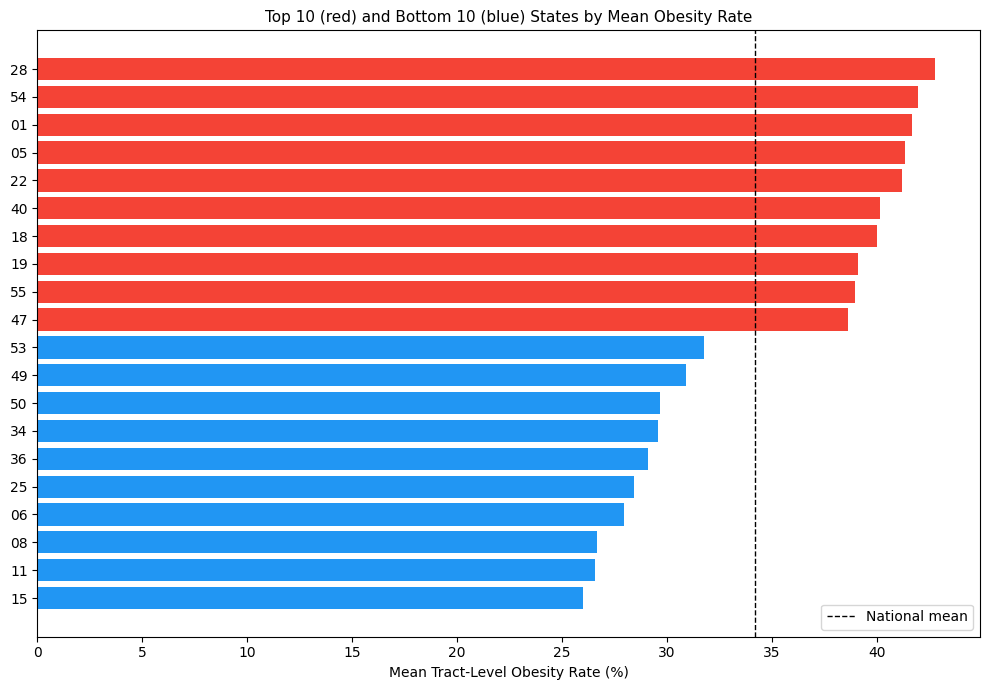


Most obese states (state FIPS):
            mean_obesity  n_tracts
state_fips                        
47               38.6000      1269
55               39.0000      1264
19               39.1000       762
18               40.0000      1309
40               40.2000       862
22               41.2000       843
05               41.3000       544
01               41.7000       924
54               41.9000       423
28               42.8000       449

Least obese states (state FIPS):
            mean_obesity  n_tracts
state_fips                        
15               26.0000       193
11               26.6000       151
08               26.7000      1047
06               28.0000      6786
25               28.4000      1299
36               29.1000      4265
34               29.6000      1814
50               29.7000       164
49               30.9000       477
53               31.7000      1148


In [218]:
# Extract 2-digit state FIPS from GEOID_tract
df['state_fips'] = df['GEOID_tract'].str[:2]

# Mean obesity by state — top 10 and bottom 10
state_obesity = (df.groupby('state_fips')['obesity_pct']
                   .agg(['mean', 'std', 'count'])
                   .rename(columns={'mean': 'mean_obesity', 'std': 'std_obesity', 'count': 'n_tracts'})
                   .sort_values('mean_obesity'))

top10    = state_obesity.tail(10)
bottom10 = state_obesity.head(10)
both     = pd.concat([bottom10, top10])

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#2196F3'] * 10 + ['#F44336'] * 10
bars = ax.barh(both.index, both['mean_obesity'], color=colors, edgecolor='none')
ax.set_xlabel('Mean Tract-Level Obesity Rate (%)')
ax.set_title('Top 10 (red) and Bottom 10 (blue) States by Mean Obesity Rate', fontsize=11)
ax.axvline(df['obesity_pct'].mean(), color='black', linestyle='--', linewidth=1, label='National mean')
ax.legend()
plt.tight_layout()
plt.savefig('../data/state_obesity.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nMost obese states (state FIPS):')
print(top10[['mean_obesity', 'n_tracts']].round(1).to_string())
print('\nLeast obese states (state FIPS):')
print(bottom10[['mean_obesity', 'n_tracts']].round(1).to_string())

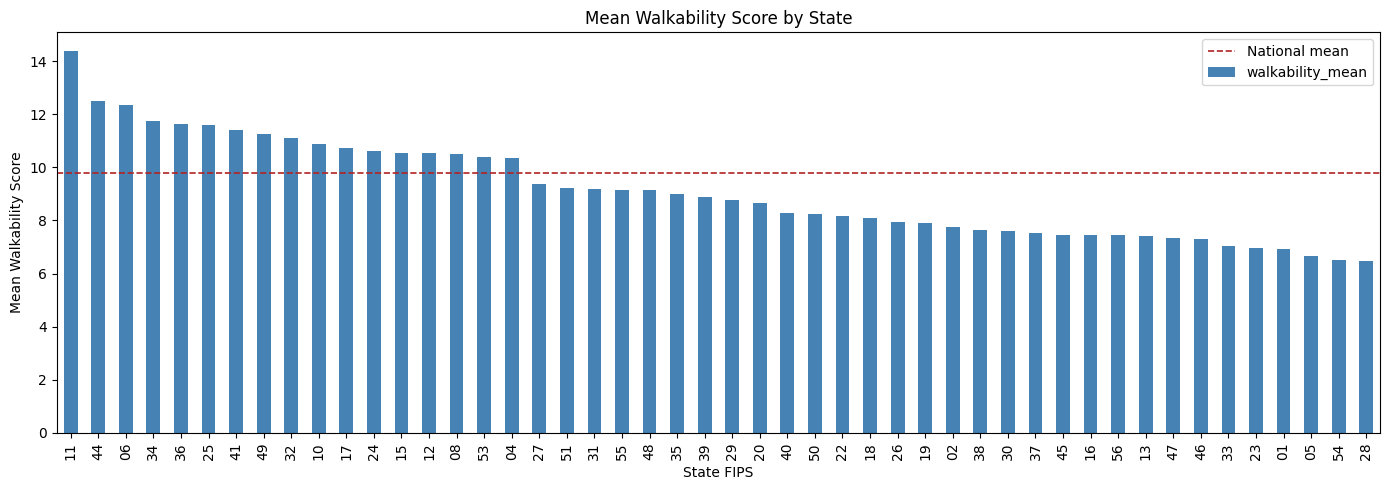

In [219]:
# Mean walkability by state — national picture
state_walk = (df.groupby('state_fips')['walkability_mean']
                .mean()
                .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(14, 5))
state_walk.plot(kind='bar', ax=ax, color='steelblue', edgecolor='none')
ax.axhline(df['walkability_mean'].mean(), color='firebrick', linestyle='--', linewidth=1.2, label='National mean')
ax.set_xlabel('State FIPS')
ax.set_ylabel('Mean Walkability Score')
ax.set_title('Mean Walkability Score by State', fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig('../data/state_walkability.png', dpi=150, bbox_inches='tight')
plt.show()

In [220]:
df = df.merge(
    food_slim,
    left_on='GEOID_tract',
    right_on='CensusTract',
    how='left'
).drop(columns='CensusTract')

print(f'Shape after demographics merge: {df.shape}')
print(f'\nNulls:\n{df.isnull().sum()}')
df.head()

Shape after demographics merge: (55975, 23)

Nulls:
GEOID_tract                 0
walkability_mean            0
walkability_min             0
walkability_max             0
diabetes_pct                0
obesity_pct                 0
nhw_pct                     0
black_pct                   0
hispanic_pct                0
no_vehicle_ratio            0
MHI                         0
state_fips                  0
LILATracts_1And10           1
LILATracts_halfAnd10        1
LILATracts_Vehicle          1
LowIncomeTracts             1
lapop1share             16730
lalowi1share            16730
lahunv1                 16730
lahunv1share            16729
PovertyRate                 1
MedianFamilyIncome        196
Urban                       1
dtype: int64


,GEOID_tract,walkability_mean,walkability_min,walkability_max,diabetes_pct,obesity_pct,nhw_pct,black_pct,hispanic_pct,no_vehicle_ratio,MHI,state_fips,LILATracts_1And10,LILATracts_halfAnd10,LILATracts_Vehicle,LowIncomeTracts,lapop1share,lalowi1share,lahunv1,lahunv1share,PovertyRate,MedianFamilyIncome,Urban
0,01001020100,4.0833,2.6667,5.5000,13.3000,39.4000,0.7076,0.0897,0.1065,0.0536,62407.0000,01,0.0000,0.0000,0.0000,0.0000,99.1890,24.1108,5.4904,0.7923,11.3365,81250.0000,1.0000
1,01001020200,8.5833,7.6667,9.5000,15.8000,44.7000,0.4175,0.4541,0.0114,0.0647,59028.0000,01,1.0000,1.0000,0.0000,1.0000,58.1102,27.8292,66.9035,9.0045,17.8768,49000.0000,1.0000
2,01001020300,6.8333,4.6667,9.0000,13.9000,40.3000,0.6623,0.2703,0.0108,0.0830,66698.0000,01,0.0000,0.0000,0.0000,0.0000,46.0037,14.1791,0.0000,0.0000,15.0460,62609.0000,1.0000
3,01001020400,7.5417,6.0000,10.0000,12.8000,36.9000,0.8692,0.0616,0.0199,0.0619,75956.0000,01,0.0000,0.0000,0.0000,0.0000,31.0868,7.8253,7.9414,0.4612,2.8452,70607.0000,1.0000
4,01001020600,4.5833,4.5000,4.6667,13.5000,40.7000,0.6815,0.2034,0.0645,0.0228,75375.0000,01,1.0000,1.0000,0.0000,1.0000,93.7177,43.2053,71.7098,5.4699,21.5777,69521.0000,1.0000


In [221]:
df.describe()

,walkability_mean,walkability_min,walkability_max,diabetes_pct,obesity_pct,nhw_pct,black_pct,hispanic_pct,no_vehicle_ratio,MHI,LILATracts_1And10,LILATracts_halfAnd10,LILATracts_Vehicle,LowIncomeTracts,lapop1share,lalowi1share,lahunv1,lahunv1share,PovertyRate,MedianFamilyIncome,Urban
count,55975.0000,55975.0000,55975.0000,55975.0000,55975.0000,55975.0000,55975.0000,55975.0000,55975.0000,55975.0000,55974.0000,55974.0000,55974.0000,55974.0000,39245.0000,39245.0000,39245.0000,39246.0000,55974.0000,55779.0000,55974.0000
mean,9.7908,8.2224,11.3874,12.6461,34.1874,0.5778,0.1339,0.1834,0.0912,83359.9968,0.1281,0.2886,0.1324,0.4295,53.1543,16.1130,36.1475,2.6441,15.2904,76908.8578,0.7714
std,4.0155,4.0721,4.2870,4.0224,7.5230,0.2953,0.2126,0.2180,0.1233,40962.2670,0.3342,0.4531,0.3389,0.4950,37.3003,15.5142,51.8601,4.0485,11.6707,38203.0722,0.4199
min,1.0000,1.0000,1.0000,0.9000,11.6000,0.0000,0.0000,0.0000,0.0000,2499.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2499.0000,0.0000
25%,6.3333,4.8333,7.6667,10.0000,28.8000,0.3437,0.0081,0.0357,0.0227,55500.0000,0.0000,0.0000,0.0000,0.0000,16.0203,3.1433,4.2691,0.3057,6.6078,50968.5000,1.0000
50%,9.5000,7.5000,11.6667,12.1000,34.3000,0.6473,0.0397,0.0955,0.0508,74077.0000,0.0000,0.0000,0.0000,0.0000,52.6968,11.5208,19.2753,1.3785,12.1833,68287.0000,1.0000
75%,13.3333,11.6667,15.1667,14.6000,39.2000,0.8344,0.1501,0.2401,0.1053,101085.0000,0.0000,1.0000,0.0000,1.0000,94.8432,25.4518,48.4475,3.4312,20.8315,93523.0000,1.0000
max,19.8333,19.8333,20.0000,50.8000,61.6000,1.0000,1.0000,1.0000,0.9736,250001.0000,1.0000,1.0000,1.0000,1.0000,100.0000,100.0000,1794.2612,78.4891,99.5086,250001.0000,1.0000


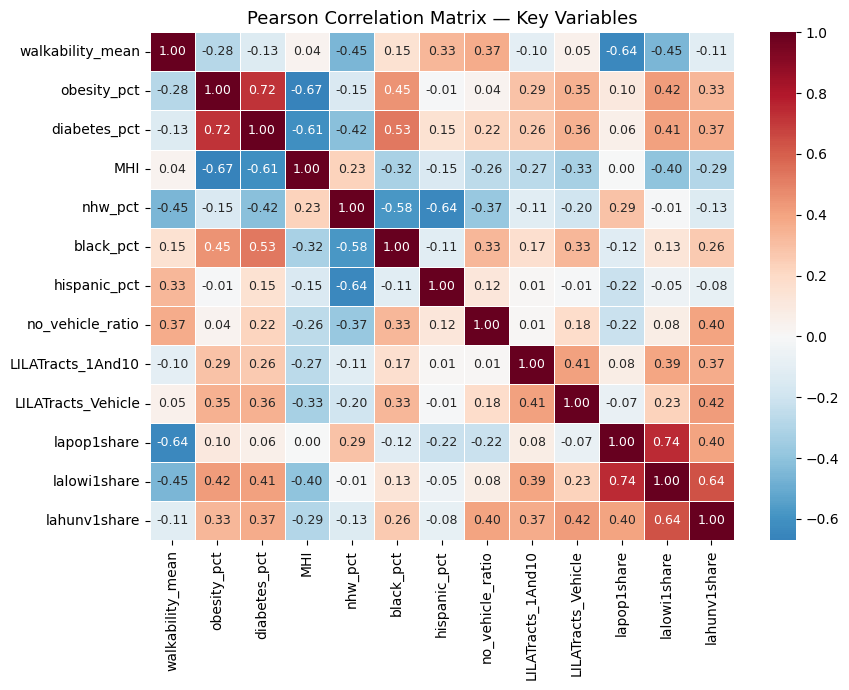

In [222]:
corr_cols = ['walkability_mean', 'obesity_pct', 'diabetes_pct', 'MHI', 'nhw_pct', 'black_pct', 'hispanic_pct', 'no_vehicle_ratio', 'LILATracts_1And10',	
'LILATracts_Vehicle', 'lapop1share', 'lalowi1share', 'lahunv1share']

corr = df[corr_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Pearson Correlation Matrix — Key Variables', fontsize=13)
plt.tight_layout()
plt.savefig('../data/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### 8f. Regional Patterns & Outlier Tracts

In [223]:
# Map 2-digit state FIPS → Census region
region_map = {
    '09': 'Northeast', '23': 'Northeast', '25': 'Northeast', '33': 'Northeast',
    '44': 'Northeast', '50': 'Northeast', '34': 'Northeast', '36': 'Northeast',
    '42': 'Northeast',
    '17': 'Midwest',   '18': 'Midwest',   '26': 'Midwest',   '39': 'Midwest',
    '55': 'Midwest',   '19': 'Midwest',   '20': 'Midwest',   '27': 'Midwest',
    '29': 'Midwest',   '31': 'Midwest',   '38': 'Midwest',   '46': 'Midwest',
    '10': 'South',     '11': 'South',     '12': 'South',     '13': 'South',
    '24': 'South',     '37': 'South',     '45': 'South',     '51': 'South',
    '54': 'South',     '01': 'South',     '21': 'South',     '28': 'South',
    '47': 'South',     '05': 'South',     '22': 'South',     '40': 'South',
    '48': 'South',
    '04': 'West',      '08': 'West',      '16': 'West',      '30': 'West',
    '32': 'West',      '35': 'West',      '49': 'West',      '56': 'West',
    '02': 'West',      '06': 'West',      '15': 'West',      '41': 'West',
    '53': 'West',
}

df['region'] = df['state_fips'].map(region_map).fillna('Other')
print(df['region'].value_counts())


region
South        19282
Midwest      15137
West         13241
Northeast     8315
Name: count, dtype: int64


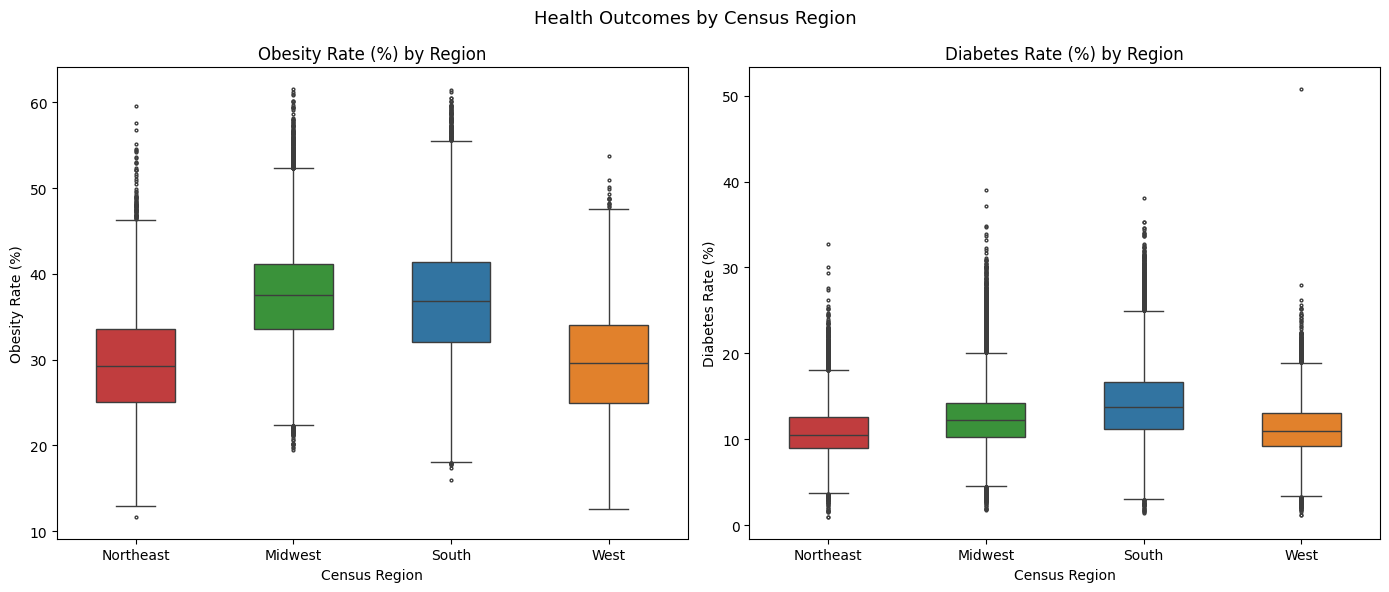

In [224]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Health Outcomes by Census Region', fontsize=13)

region_order = ['Northeast', 'Midwest', 'South', 'West']
palette = {'Northeast': '#4C72B0', 'Midwest': '#DD8452',
           'South': '#55A868', 'West': '#C44E52'}

for ax, (col, label) in zip(axes, [('obesity_pct', 'Obesity Rate (%)'),
                                     ('diabetes_pct', 'Diabetes Rate (%)')]):
    sns.boxplot(data=df[df['region'].isin(region_order)],
                x='region', hue = 'region', y=col, order=region_order,
                legend = False, width=0.5, fliersize=2, ax=ax)
    ax.set_xlabel('Census Region')
    ax.set_ylabel(label)
    ax.set_title(label + ' by Region')

plt.tight_layout()
plt.savefig('../data/regional_health_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

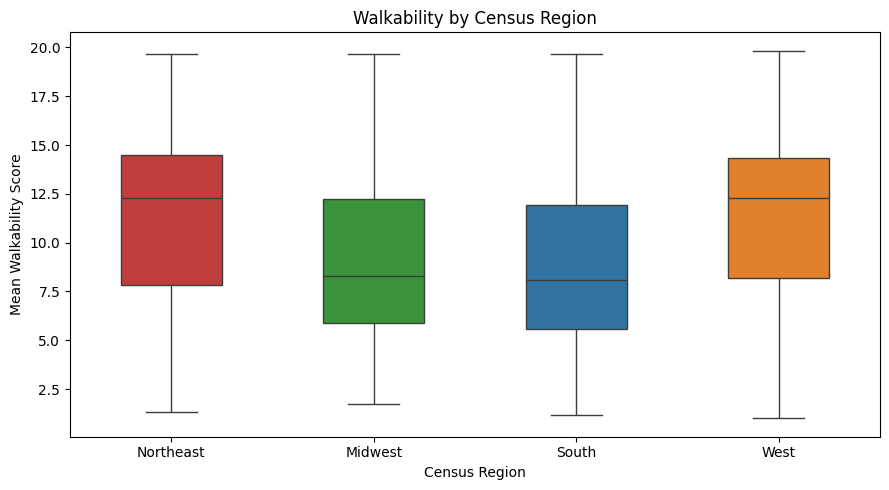

In [225]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.boxplot(data=df[df['region'].isin(region_order)],
            x='region', hue='region', y='walkability_mean', order=region_order,
            legend=False, width=0.5, fliersize=2, ax=ax)
ax.set_xlabel('Census Region')
ax.set_ylabel('Mean Walkability Score')
ax.set_title('Walkability by Census Region')
plt.tight_layout()
plt.savefig('../data/regional_walkability_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()


In [226]:
region_summary = (
    df[df['region'].isin(region_order)]
    .groupby('region')[['walkability_mean', 'obesity_pct', 'diabetes_pct',
                         'MHI', 'LILATracts_1And10']]
    .agg(['mean', 'median'])
    .round(2)
)
region_summary.columns = ['_'.join(c) for c in region_summary.columns]
region_summary


,walkability_mean_mean,walkability_mean_median,obesity_pct_mean,obesity_pct_median,diabetes_pct_mean,diabetes_pct_median,MHI_mean,MHI_median,LILATracts_1And10_mean,LILATracts_1And10_median
region,,,,,,,,,,
Midwest,8.9900,8.2900,37.4600,37.5000,12.6700,12.2000,75388.1800,70291.0000,0.1300,0.0000
Northeast,11.3100,12.2800,29.4700,29.3000,11.0200,10.5000,97712.2300,89007.0000,0.0500,0.0000
South,8.7100,8.0800,36.7800,36.8000,14.2700,13.7000,74794.0000,64995.5000,0.1800,0.0000
West,11.3200,12.2800,29.6500,29.6000,11.2800,11.0000,95934.5800,86863.0000,0.0900,0.0000


#### Outlier Tracts - Z-score method

Flag tracts that are extreme on **walkability**, **obesity**, or **diabetes** (|z| > 3). These are candidates for data quality checks or represent genuinely unusual communities.

In [227]:
from scipy import stats

z_cols = ['walkability_mean', 'obesity_pct', 'diabetes_pct']
z = df[z_cols].apply(stats.zscore, nan_policy='omit')
z.columns = [c + '_z' for c in z_cols]

df_z = pd.concat([df, z], axis=1)

# Flag any tract with |z| > 3 on at least one variable
outlier_mask = (z.abs() > 3).any(axis=1)
outliers = df_z[outlier_mask].copy()

print(f'Outlier tracts (|z| > 3 on any key variable): {outlier_mask.sum():,}')
print(f'  Walk outliers : {(z["walkability_mean_z"].abs() > 3).sum()}')
print(f'  Obesity outliers  : {(z["obesity_pct_z"].abs() > 3).sum()}')
print(f'  Diabetes outliers : {(z["diabetes_pct_z"].abs() > 3).sum()}')


Outlier tracts (|z| > 3 on any key variable): 742
  Walk outliers : 0
  Obesity outliers  : 107
  Diabetes outliers : 719


In [228]:
# Top walkability outliers (very low)
low_walk = (df_z.nsmallest(10, 'walkability_mean_z')
              [['GEOID_tract', 'state_fips', 'region',
                'walkability_mean', 'obesity_pct', 'diabetes_pct', 'MHI']]
              .round(2))
print('=== Lowest walkability tracts ===')
display(low_walk)

# Top walkability outliers (very high)
high_walk = (df_z.nlargest(10, 'walkability_mean_z')
               [['GEOID_tract', 'state_fips', 'region',
                 'walkability_mean', 'obesity_pct', 'diabetes_pct', 'MHI']]
               .round(2))
print('Highest walkability tracts')
display(high_walk)


=== Lowest walkability tracts ===


,GEOID_tract,state_fips,region,walkability_mean,obesity_pct,diabetes_pct,MHI
1124,04005942202,04,West,1.0000,34.1000,19.7000,36736.0000
1143,04007940200,04,West,1.0000,43.4000,21.0000,36523.0000
34220,35053940000,35,West,1.0000,48.8000,24.1000,25245.0000
2006,04017940014,04,West,1.0600,47.5000,26.2000,27198.0000
2002,04017940010,04,West,1.1100,48.1000,24.5000,17377.0000
514,01087232300,01,South,1.1700,49.1000,23.9000,40974.0000
34166,35045943100,35,West,1.1700,40.4000,22.2000,30139.0000
764,01105686800,01,South,1.2500,44.5000,19.7000,45784.0000
1069,04001942600,04,West,1.2500,39.9000,21.5000,28661.0000
29201,28089031000,28,South,1.3300,43.8000,20.0000,39955.0000


Highest walkability tracts


,GEOID_tract,state_fips,region,walkability_mean,obesity_pct,diabetes_pct,MHI
44227,41051001102,41,West,19.8300,26.0000,6.0000,106875.0000
3230,06001983200,06,West,19.6700,23.3000,7.8000,181250.0000
5986,06053001300,06,West,19.6700,35.6000,14.5000,61585.0000
10017,08031002000,08,West,19.6700,20.1000,4.8000,106688.0000
12778,12086006203,12,South,19.6700,23.4000,12.2000,97706.0000
16141,17031062500,17,Midwest,19.6700,26.2000,5.4000,169917.0000
37544,36081116700,36,Northeast,19.6700,20.4000,17.4000,55216.0000
6026,06053012302,06,West,19.5000,25.4000,9.3000,114682.0000
7948,06073012302,06,West,19.5000,28.9000,13.9000,44750.0000
8632,06081610202,06,West,19.5000,21.9000,5.1000,179052.0000


In [229]:
# Highest obesity tracts
high_ob = (df_z.nlargest(10, 'obesity_pct_z')
             [['GEOID_tract', 'state_fips', 'region',
               'walkability_mean', 'obesity_pct', 'diabetes_pct', 'MHI',
               'LILATracts_1And10']]
             .round(2))
print('=== Highest obesity tracts ===')
display(high_ob)

# Highest diabetes tracts
high_db = (df_z.nlargest(10, 'diabetes_pct_z')
             [['GEOID_tract', 'state_fips', 'region',
               'walkability_mean', 'obesity_pct', 'diabetes_pct', 'MHI',
               'LILATracts_1And10']]
             .round(2))
print('=== Highest diabetes tracts ===')
display(high_db)


=== Highest obesity tracts ===


,GEOID_tract,state_fips,region,walkability_mean,obesity_pct,diabetes_pct,MHI,LILATracts_1And10
55200,55079008700,55,Midwest,13.3300,61.6000,30.1000,14009.0000,0.0000
14355,13021011500,13,South,9.3300,61.5000,34.6000,12107.0000,0.0000
22212,22073010700,22,South,6.2500,61.2000,32.0000,15536.0000,1.0000
26552,26121004300,26,Midwest,8.8300,61.2000,25.2000,24158.0000,1.0000
18825,17201002600,17,Midwest,8.0800,61.0000,22.4000,15500.0000,0.0000
26524,26121001300,26,Midwest,7.4400,60.9000,24.0000,29434.0000,1.0000
692,01101001200,01,South,14.8300,60.5000,28.0000,20739.0000,0.0000
46493,47113001100,47,South,5.3300,60.5000,29.5000,35798.0000,0.0000
18123,17115000600,17,Midwest,7.3900,60.2000,24.3000,18286.0000,0.0000
21701,22019000200,22,South,6.8300,60.2000,31.3000,22451.0000,1.0000


=== Highest diabetes tracts ===


,GEOID_tract,state_fips,region,walkability_mean,obesity_pct,diabetes_pct,MHI,LILATracts_1And10
8382,06075980501,06,West,14.3300,14.4000,50.8000,13569.0000,0.0000
40766,39035112100,39,Midwest,12.5800,53.1000,39.0000,11511.0000,0.0000
48454,48141001800,48,South,16.5800,47.7000,38.1000,12899.0000,0.0000
40913,39035152701,39,Midwest,13.6700,52.3000,37.1000,18581.0000,0.0000
600,01097001501,01,South,7.0000,57.8000,35.3000,14399.0000,1.0000
48456,48141002000,48,South,13.5600,46.6000,35.3000,12798.0000,0.0000
40783,39035117201,39,Midwest,12.9400,53.6000,34.8000,16039.0000,0.0000
40759,39035109301,39,Midwest,11.6700,55.9000,34.7000,11036.0000,0.0000
647,01097004800,01,South,6.2500,58.7000,34.6000,9153.0000,0.0000
14355,13021011500,13,South,9.3300,61.5000,34.6000,12107.0000,0.0000


In [230]:
# Unusual combos: high walkability but high obesity (potential confounders)
surprising = df_z[
    (df_z['walkability_mean_z'] > 1) &   # above-average walkability
    (df_z['obesity_pct_z'] > 1.5)        # well above-average obesity
].sort_values('obesity_pct', ascending=False)

print(f'High-walk, high-obesity tracts: {len(surprising)}')
display(surprising[['GEOID_tract', 'state_fips', 'region',
                     'walkability_mean', 'obesity_pct', 'diabetes_pct',
                     'MHI', 'nhw_pct', 'black_pct', 'hispanic_pct',
                     'LILATracts_1And10']].head(15).round(2))


High-walk, high-obesity tracts: 560


,GEOID_tract,state_fips,region,walkability_mean,obesity_pct,diabetes_pct,MHI,nhw_pct,black_pct,hispanic_pct,LILATracts_1And10
692,01101001200,01,South,14.8300,60.5000,28.0000,20739.0000,0.0000,0.9700,0.0100,0.0000
25636,26049003400,26,Midwest,14.4200,59.7000,19.4000,7401.0000,0.1100,0.8600,0.0000,0.0000
705,01101002400,01,South,14.8300,59.6000,31.5000,21607.0000,0.0000,0.9600,0.0000,1.0000
36782,36067004200,36,Northeast,15.9200,59.6000,24.4000,15439.0000,0.0700,0.5900,0.2400,0.0000
55185,55079007000,55,Midwest,14.1200,59.5000,27.2000,20673.0000,0.0700,0.7800,0.0900,0.0000
52851,51760030100,51,South,13.8300,59.0000,27.9000,16732.0000,0.0400,0.9100,0.0000,0.0000
690,01101001000,01,South,14.8300,58.6000,25.3000,32336.0000,0.0900,0.8700,0.0300,1.0000
52748,51710004200,51,South,14.5000,58.5000,32.4000,13566.0000,0.1600,0.7700,0.0700,0.0000
2740,05119002600,05,South,15.0800,58.1000,28.9000,30602.0000,0.1300,0.8700,0.0000,1.0000
18484,17167001600,17,Midwest,14.2100,57.9000,24.9000,22284.0000,0.2300,0.7000,0.0300,0.0000


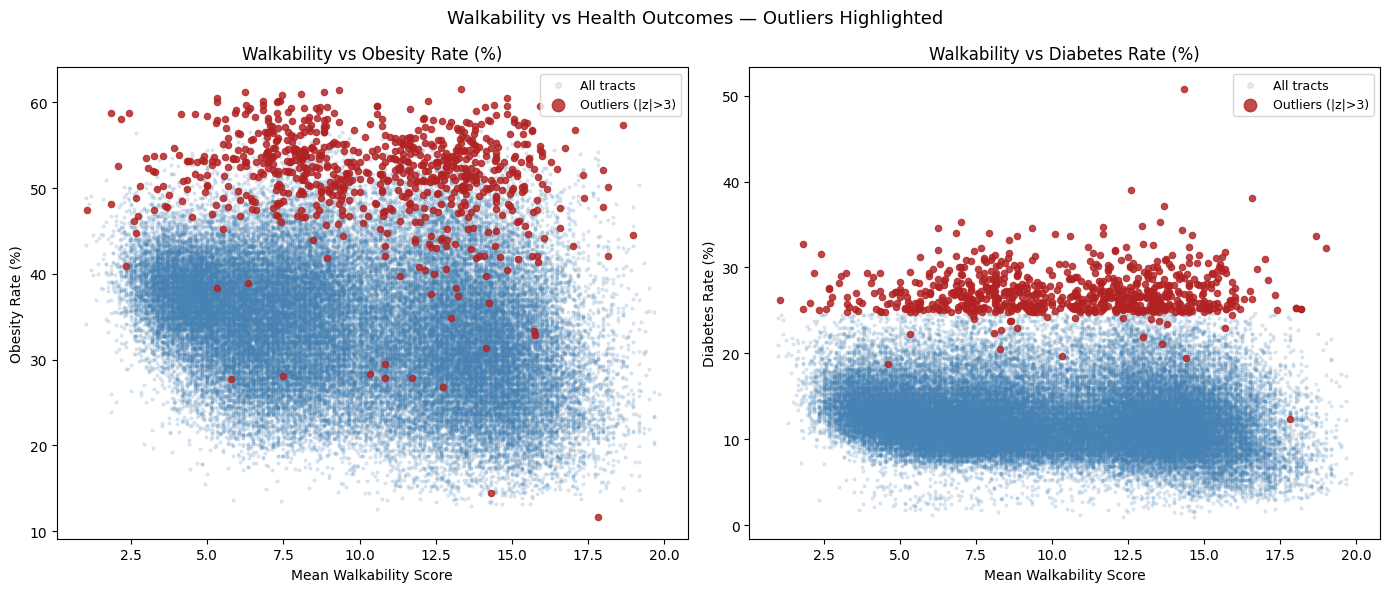

In [231]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Walkability vs Health Outcomes — Outliers Highlighted', fontsize=13)

for ax, (y_col, label) in zip(axes, [('obesity_pct', 'Obesity Rate (%)'),
                                       ('diabetes_pct', 'Diabetes Rate (%)')]):
    # All tracts (faint)
    ax.scatter(df_z['walkability_mean'], df_z[y_col],
               alpha=0.15, s=4, color='steelblue', label='All tracts')
    # Outliers
    ax.scatter(outliers['walkability_mean'], outliers[y_col],
               alpha=0.8, s=20, color='firebrick', label='Outliers (|z|>3)', zorder=3)
    ax.set_xlabel('Mean Walkability Score')
    ax.set_ylabel(label)
    ax.set_title(f'Walkability vs {label}')
    ax.legend(markerscale=2, fontsize=9)

plt.tight_layout()
plt.savefig('../data/outlier_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


Food desert prevalence by region:


,food_desert_pct,n_tracts
region,,
South,18.0100,19282
Midwest,13.3700,15137
West,9.4000,13240
Northeast,5.1800,8315


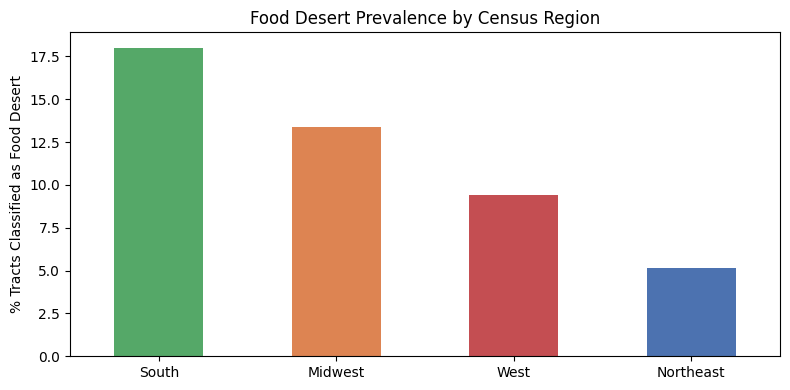

In [232]:
# Food desert prevalence by region
food_region = (
    df[df['region'].isin(region_order)]
    .groupby('region')['LILATracts_1And10']
    .agg(food_desert_pct=lambda x: 100 * x.mean(),
         n_tracts='count')
    .round(2)
    .sort_values('food_desert_pct', ascending=False)
)
print('Food desert prevalence by region:')
display(food_region)

fig, ax = plt.subplots(figsize=(8, 4))
food_region['food_desert_pct'].plot(kind='bar', ax=ax,
                                    color=[palette[r] for r in food_region.index],
                                    edgecolor='none')
ax.set_ylabel('% Tracts Classified as Food Desert')
ax.set_title('Food Desert Prevalence by Census Region')
ax.set_xlabel('')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../data/regional_food_desert.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Regression Modeling - Week 3

All models use **sklearn** with 80/20 train-test split cross-validation. Both obesity and diabetes are modeled.  
Features: walkability, food desert flag, food access shares, income, race, car ownership.

In [233]:
display(df_z)

,GEOID_tract,walkability_mean,walkability_min,walkability_max,diabetes_pct,obesity_pct,nhw_pct,black_pct,hispanic_pct,no_vehicle_ratio,MHI,state_fips,LILATracts_1And10,LILATracts_halfAnd10,LILATracts_Vehicle,LowIncomeTracts,lapop1share,lalowi1share,lahunv1,lahunv1share,PovertyRate,MedianFamilyIncome,Urban,region,walkability_mean_z,obesity_pct_z,diabetes_pct_z
0,01001020100,4.0833,2.6667,5.5000,13.3000,39.4000,0.7076,0.0897,0.1065,0.0536,62407.0000,01,0.0000,0.0000,0.0000,0.0000,99.1890,24.1108,5.4904,0.7923,11.3365,81250.0000,1.0000,South,-1.4214,0.6929,0.1626
1,01001020200,8.5833,7.6667,9.5000,15.8000,44.7000,0.4175,0.4541,0.0114,0.0647,59028.0000,01,1.0000,1.0000,0.0000,1.0000,58.1102,27.8292,66.9035,9.0045,17.8768,49000.0000,1.0000,South,-0.3007,1.3974,0.7841
2,01001020300,6.8333,4.6667,9.0000,13.9000,40.3000,0.6623,0.2703,0.0108,0.0830,66698.0000,01,0.0000,0.0000,0.0000,0.0000,46.0037,14.1791,0.0000,0.0000,15.0460,62609.0000,1.0000,South,-0.7365,0.8125,0.3117
3,01001020400,7.5417,6.0000,10.0000,12.8000,36.9000,0.8692,0.0616,0.0199,0.0619,75956.0000,01,0.0000,0.0000,0.0000,0.0000,31.0868,7.8253,7.9414,0.4612,2.8452,70607.0000,1.0000,South,-0.5601,0.3606,0.0383
4,01001020600,4.5833,4.5000,4.6667,13.5000,40.7000,0.6815,0.2034,0.0645,0.0228,75375.0000,01,1.0000,1.0000,0.0000,1.0000,93.7177,43.2053,71.7098,5.4699,21.5777,69521.0000,1.0000,South,-1.2968,0.8657,0.2123
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55970,56043000200,5.5000,3.6667,6.8333,13.3000,32.7000,0.8933,0.0045,0.0756,0.0225,61293.0000,56,0.0000,0.0000,0.0000,0.0000,81.5997,20.2868,33.7608,2.5635,9.7296,67254.0000,0.0000,West,-1.0686,-0.1977,0.1626
55971,56043000301,10.5556,7.8333,13.3333,13.5000,34.8000,0.7594,0.0000,0.2083,0.0660,61832.0000,56,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,11.5833,64152.0000,1.0000,West,0.1905,0.0814,0.2123
55972,56043000302,7.1667,6.0000,8.3333,15.0000,33.7000,0.7537,0.0000,0.1646,0.0405,65114.0000,56,0.0000,0.0000,0.0000,0.0000,6.1109,1.7192,2.6725,0.2618,16.3290,69605.0000,1.0000,West,-0.6535,-0.0648,0.5852
55973,56045951100,5.1667,5.0000,5.3333,13.6000,37.3000,0.8085,0.0012,0.0307,0.0081,89202.0000,56,0.0000,0.0000,0.0000,0.0000,68.8747,20.7277,13.2164,0.9997,17.4608,74500.0000,0.0000,West,-1.1516,0.4137,0.2371


### 9a. OLS - Ordinary Least Squares

In [234]:
import statsmodels.formula.api as smf

ols_diabetes = smf.ols(formula="diabetes_pct ~ walkability_mean + LILATracts_1And10 + no_vehicle_ratio + MHI + black_pct + hispanic_pct", data=df).fit(cov_type='HC3')
ols_obesity = smf.ols(formula="obesity_pct ~ walkability_mean + LILATracts_1And10 + no_vehicle_ratio + MHI + black_pct + hispanic_pct", data=df).fit(cov_type='HC3')
print(ols_diabetes.summary())
print(ols_obesity.summary())

                            OLS Regression Results                            
Dep. Variable:           diabetes_pct   R-squared:                       0.559
Model:                            OLS   Adj. R-squared:                  0.559
Method:                 Least Squares   F-statistic:                     7333.
Date:                Sun, 26 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:40:19   Log-Likelihood:            -1.3442e+05
No. Observations:               55974   AIC:                         2.689e+05
Df Residuals:                   55967   BIC:                         2.689e+05
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            16.3964      0.04

In [235]:
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=cols)
features = ["walkability_mean", "lapop1share", "no_vehicle_ratio", "MHI", "black_pct", "hispanic_pct"]
df = df.dropna(subset=features)
vif_data = pd.DataFrame()
vif_data["variable"] = ["walkability_mean", "lapop1share", "no_vehicle_ratio", "MHI", "black_pct", "hispanic_pct"]
vif_data["VIF"] = [variance_inflation_factor(df[vif_data["variable"]].values, i) for i in range(6)]
print(vif_data)


           variable    VIF
0  walkability_mean 7.3412
1       lapop1share 2.3999
2  no_vehicle_ratio 2.6022
3               MHI 5.6699
4         black_pct 1.7062
5      hispanic_pct 1.7417


### 9b. Ridge Regression

In [236]:
from sklearn.datasets import make_regression
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score

In [237]:
ridge = Pipeline([('scaler', StandardScaler()),  ('model',  Ridge(alpha=1.0))])
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

features = ["walkability_mean", "lapop1share", "no_vehicle_ratio", "MHI", "black_pct", "hispanic_pct"]
target = "diabetes_pct"

x = df[features]
y = df[target]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
ridge.fit(x_train, y_train)

train_r2 = r2_score(y_train, ridge.predict(x_train))
test_r2 = r2_score(y_test, ridge.predict(x_test))

print(f"Train R²: {train_r2:.4f}")
print(f"Test R²:  {test_r2:.4f}")

coefficients = ridge.named_steps['model'].coef_
for name, coef in zip(features, coefficients):
    print(f"{name}: {coef:.4f}")

Train R²: 0.5843
Test R²:  0.5840
walkability_mean: -0.8770
lapop1share: 0.1457
no_vehicle_ratio: 0.6780
MHI: -1.4779
black_pct: 1.5534
hispanic_pct: 0.5808


## 10. Random Forest - Week 4

### 10a. Train Models for Obesity & Diabetes

In [238]:
from sklearn.ensemble import RandomForestRegressor

randomforest = Pipeline([('scaler', StandardScaler()), ('model', RandomForestRegressor(n_estimators=100, random_state=42))])

randomforest.fit(x_train, y_train)
print(f"Train R²: {r2_score(y_train, randomforest.predict(x_train)):.3f}")
print(f"Test R²:  {r2_score(y_test, randomforest.predict(x_test)):.3f}")

Train R²: 0.957
Test R²:  0.688


In [239]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'model__max_depth': [3, 5, 10, None],
    'model__min_samples_leaf': [10, 50, 100],
    'model__max_features': [0.5, 0.75, 1.0]
}

grid_search = GridSearchCV(randomforest, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(x_train, y_train)

print(f"Best params: {grid_search.best_params_}")
print(f"Test R²: {r2_score(y_test, grid_search.predict(x_test)):.3f}")

Best params: {'model__max_depth': None, 'model__max_features': 0.5, 'model__min_samples_leaf': 10}
Test R²: 0.700


In [240]:
for depth in [3, 5, 10, None]:
    rf_test = Pipeline([
        ('scaler', StandardScaler()),
        ('model', RandomForestRegressor(max_depth=depth, n_estimators=100, random_state=42))
    ])
    rf_test.fit(x_train, y_train)
    train_r2 = r2_score(y_train, rf_test.predict(x_train))
    test_r2 = r2_score(y_test, rf_test.predict(x_test))
    print(f"max_depth={depth}: Train={train_r2:.3f}, Test={test_r2:.3f}")

max_depth=3: Train=0.604, Test=0.601
max_depth=5: Train=0.672, Test=0.664
max_depth=10: Train=0.773, Test=0.695
max_depth=None: Train=0.957, Test=0.688


In [241]:
from sklearn.ensemble import RandomForestRegressor

randomforest_adj = Pipeline([('scaler', StandardScaler()), ('model', RandomForestRegressor(
        n_estimators=100,
        max_depth=10,          
        min_samples_leaf=50,  
        max_features=0.5,
        random_state=42))])

randomforest_adj.fit(x_train, y_train)
print(f"Adjusted Train R²: {r2_score(y_train, randomforest_adj.predict(x_train)):.3f}")
print(f"Adjusted Test R²:  {r2_score(y_test, randomforest_adj.predict(x_test)):.3f}")

Adjusted Train R²: 0.715
Adjusted Test R²:  0.694


### 11. Gradient Boosting

In [242]:
from sklearn.ensemble import GradientBoostingRegressor

gb = Pipeline([('scaler', StandardScaler()), ('model', GradientBoostingRegressor(n_estimators=100, random_state=42))])

gb.fit(x_train, y_train)
print(f"Train R²: {r2_score(y_train, gb.predict(x_train)):.3f}")
print(f"Test R²:  {r2_score(y_test, gb.predict(x_test)):.3f}")

Train R²: 0.718
Test R²:  0.701


In [243]:
rf_importances = randomforest_adj.named_steps['model'].feature_importances_
gb_importances = gb.named_steps['model'].feature_importances_

importance_df = pd.DataFrame({
    'feature': features,
    'Random Forest': rf_importances,
    'Gradient Boosting': gb_importances
}).sort_values('Random Forest', ascending=False)

print(importance_df)

            feature  Random Forest  Gradient Boosting
3               MHI         0.5940             0.6972
4         black_pct         0.2436             0.1950
5      hispanic_pct         0.0527             0.0469
2  no_vehicle_ratio         0.0508             0.0064
0  walkability_mean         0.0483             0.0517
1       lapop1share         0.0106             0.0028


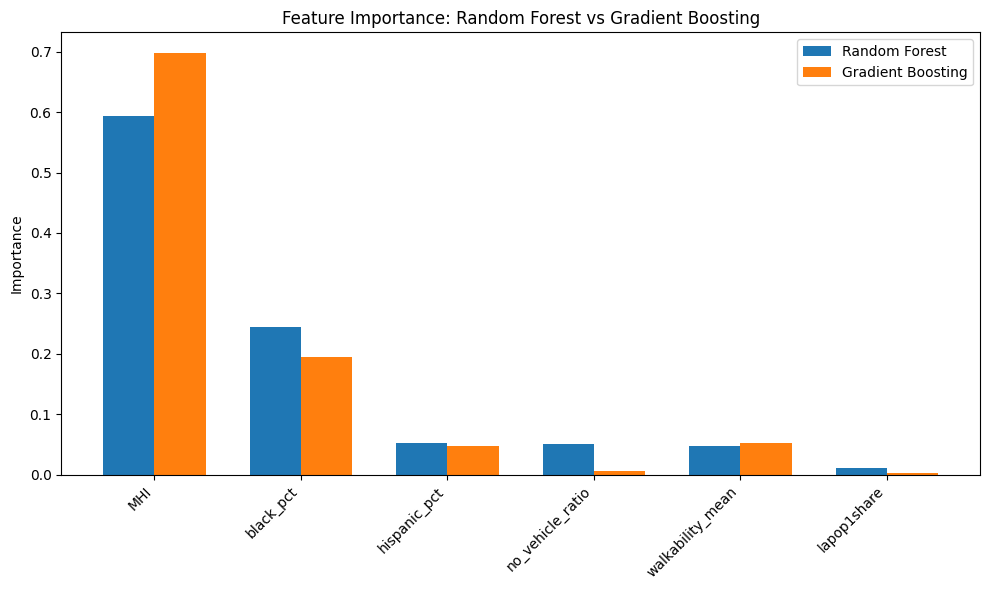

In [244]:
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(features))
width = 0.35
ax.bar(x - width/2, importance_df['Random Forest'], width, label='Random Forest')
ax.bar(x + width/2, importance_df['Gradient Boosting'], width, label='Gradient Boosting')

ax.set_xticks(x)
ax.set_xticklabels(importance_df['feature'], rotation=45, ha='right')
ax.set_ylabel('Importance')
ax.set_title('Feature Importance: Random Forest vs Gradient Boosting')
ax.legend()

plt.tight_layout()
plt.show()